# Step 6 — Game-Theoretic Mix Optimization
### gametheory-sweetcrete

We frame mix design as a **two-player game**:
- **Sustainability** wants to *maximize PCC* (displacing cement, using the sugar-beet byproduct)
- **Performance** wants to *maximize strength*

The trained model is the objective function. We compute the **Pareto-efficient frontier**
(the set of non-dominated compromises), the **Nash bargaining solution** (the fair
compromise that maximizes the product of both players' gains), and a practical
**constraint-based recommender** — *"the most PCC I can use and still hit my required strength."*

The decision variable is the PCC replacement level (a tested level), using the recipe
measured at that level — so we never extrapolate the mix proportions.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
p=Path.cwd()
while not (p/"src").exists() and p!=p.parent: p=p.parent
ROOT=p; FIG=ROOT/"results"/"figures"; FIG.mkdir(parents=True,exist_ok=True)
sys.path.insert(0,str(ROOT/"src"))
from optimize import (strength_curve, pareto_front, nash_solution,
                      recommend_max_pcc, predict_strength)

strength_curve(28).round(2)

,PCC_%,strength
0,0,40.59
1,5,38.88
2,10,36.81
3,15,32.84
4,20,37.53
5,25,28.95
6,30,33.74
7,35,29.22
8,40,18.04
9,45,17.95


## 1. The Pareto-efficient frontier
Each mix is a point in (PCC, strength) space. A mix is **dominated** if another uses more
PCC *and* is stronger — those are never rational choices. The remaining non-dominated
mixes form the Pareto frontier: the efficient trade-offs. The **Nash bargaining
solution** (★) is the fair compromise.

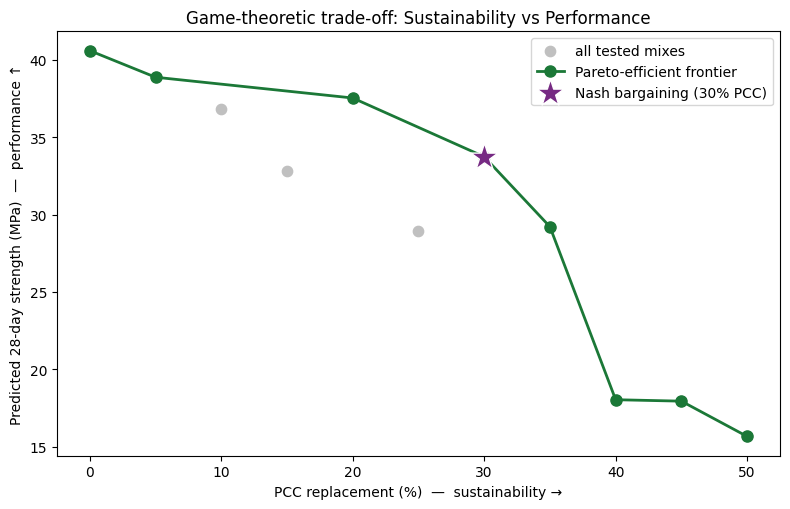

Nash bargaining solution: {'PCC_%': 30.0, 'strength': 33.73958393745504, 'age_days': 28}


In [2]:
d = pareto_front(28); nash = nash_solution(28)
fig,ax=plt.subplots(figsize=(8,5.2))
ax.scatter(d["PCC_%"],d["strength"],s=55,color="#c0c0c0",label="all tested mixes",zorder=2)
pf=d[d["pareto"]].sort_values("PCC_%")
ax.plot(pf["PCC_%"],pf["strength"],"-o",color="#1b7837",lw=2,ms=8,
        label="Pareto-efficient frontier",zorder=3)
ax.scatter([nash["PCC_%"]],[nash["strength"]],marker="*",s=420,color="#762a83",
           edgecolor="white",zorder=4,label=f"Nash bargaining ({nash['PCC_%']:.0f}% PCC)")
ax.set_xlabel("PCC replacement (%)  —  sustainability →")
ax.set_ylabel("Predicted 28-day strength (MPa)  —  performance ↑")
ax.set_title("Game-theoretic trade-off: Sustainability vs Performance")
ax.legend(); plt.tight_layout()
plt.savefig(FIG/"optimization_pareto.png",dpi=150,bbox_inches="tight"); plt.show()
print("Nash bargaining solution:", nash)

Note the **strength cliff** past ~35% PCC — strength falls sharply. The Nash solution
sits right at the knee (≈30% PCC), capturing most of the sustainability benefit before
performance collapses. This is the headline recommendation of the whole project.

## 2. Strength across the full design space
Predicted strength for every PCC level × curing age — the feasibility map an engineer reads.

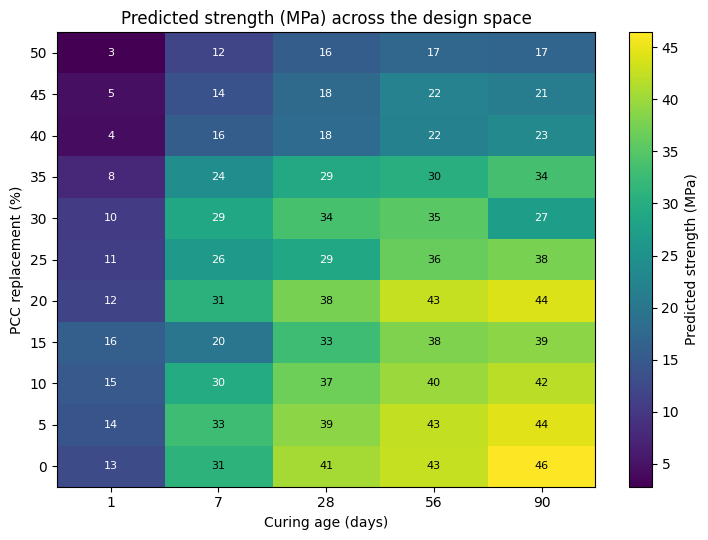

In [3]:
ages=[1,7,28,56,90]
levels=sorted(d["PCC_%"].unique())
M=np.array([[predict_strength(p_,a) for a in ages] for p_ in levels])
fig,ax=plt.subplots(figsize=(7.5,5.5))
im=ax.imshow(M,aspect="auto",cmap="viridis",origin="lower")
ax.set_xticks(range(len(ages))); ax.set_xticklabels(ages)
ax.set_yticks(range(len(levels))); ax.set_yticklabels([f"{int(p_)}" for p_ in levels])
ax.set_xlabel("Curing age (days)"); ax.set_ylabel("PCC replacement (%)")
ax.set_title("Predicted strength (MPa) across the design space")
for i in range(len(levels)):
    for j in range(len(ages)):
        ax.text(j,i,f"{M[i,j]:.0f}",ha="center",va="center",
                color="white" if M[i,j]<30 else "black",fontsize=8)
fig.colorbar(im,label="Predicted strength (MPa)")
plt.tight_layout(); plt.savefig(FIG/"optimization_heatmap.png",dpi=150,bbox_inches="tight"); plt.show()

## 3. The practical recommender
The tool engineers will actually use: give a required strength and age, get the most
sustainable (highest-PCC) mix that meets it.

In [4]:
for target in [40, 35, 30, 25, 20]:
    rec = recommend_max_pcc(target, age_days=28)
    if rec["feasible"]:
        print(f"Need >= {target} MPa @28d  ->  use {rec['PCC_%']:.0f}% PCC "
              f"(predicted {rec['predicted_strength']:.1f} MPa, margin +{rec['margin']:.1f})")
    else:
        print(f"Need >= {target} MPa @28d  ->  {rec['message']}")

Need >= 40 MPa @28d  ->  use 0% PCC (predicted 40.6 MPa, margin +0.6)


Need >= 35 MPa @28d  ->  use 20% PCC (predicted 37.5 MPa, margin +2.5)


Need >= 30 MPa @28d  ->  use 30% PCC (predicted 33.7 MPa, margin +3.7)


Need >= 25 MPa @28d  ->  use 35% PCC (predicted 29.2 MPa, margin +4.2)


Need >= 20 MPa @28d  ->  use 35% PCC (predicted 29.2 MPa, margin +9.2)


## Takeaways

- **The project's core question is answered quantitatively:** ~30% PCC (the Nash solution)
  is the balanced optimum, and up to ~35% stays viable before the strength cliff.
- **The recommender turns the model into a decision tool** — exactly the input the Step 7 GUI needs.
- All logic lives in `src/optimize.py`, so the GUI imports it directly.

**Next:** Step 7 — a Streamlit GUI wrapping the model and this optimizer for live use.